In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math


# Partie 1

In [58]:
def Rp(R,A):
    return A*R/(1-A)

def Rp_bis(Qint, omega0, C=10*1E-9):
    return Qint/(C*omega0)

def Q_int(Q,R,omega0, C=10*1E-9):
    Q_ext = R*C*omega0
    return 1/(1/Q - 1/Q_ext)

## R = 47 kOhm

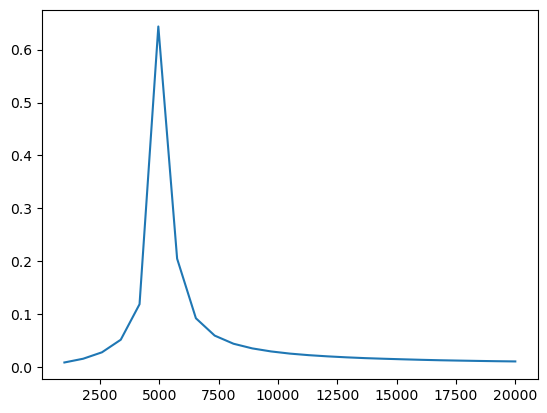

In [59]:
freq = pd.read_csv('Bode_47.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_47.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

fréquence de résonance 32273.062733491442
facteur de qualité 163.10267660168213
Rp -54296.38098616641
Rp 43000.96543210806
Q_int 13.877728549911204
Valeur attendue de Quint 15.16833948474098


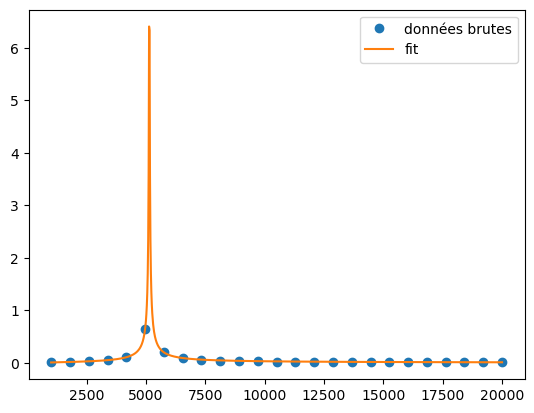

In [60]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()

R = 47*1E3
p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes')
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()
print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))

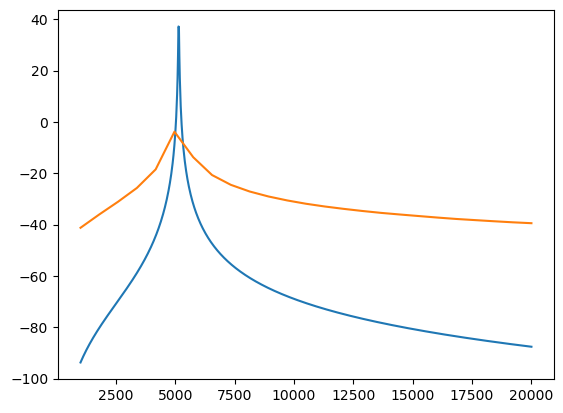

In [61]:
G_fit = 20*np.log(model(freq_np, *popt))
G_brut = gain

plt.plot(freq_np, G_fit)
plt.plot(freq, G_brut)

## R = 100 kOhm

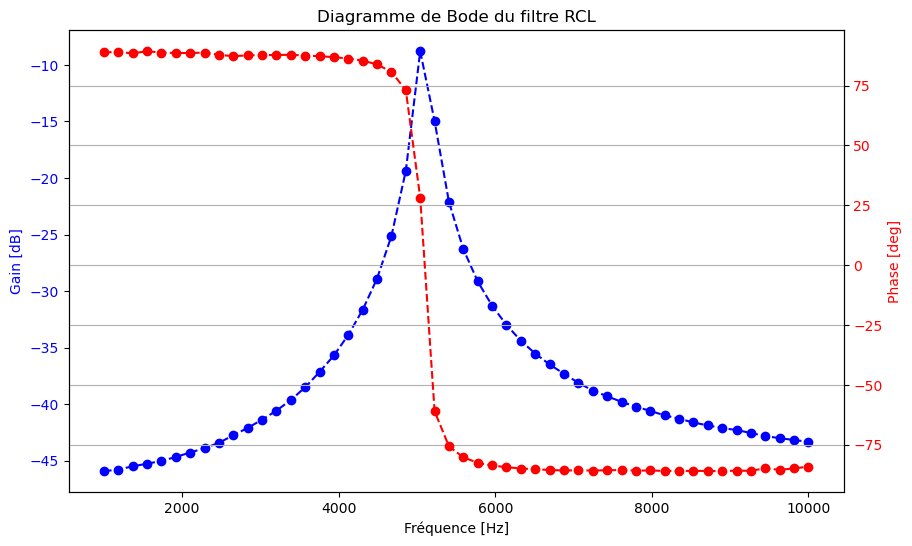

In [68]:
freq = pd.read_csv('Bode_100.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_100.csv')[' Phase [deg]']


amp = 10**(gain/20)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot California sales
plt.plot(freq, gain, marker ='o', linestyle ='--', color ='b', label ='Gain')
ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Texas sales
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title("Diagramme de Bode du filtre RCL")
plt.grid(which='both')
plt.show()

fréquence de résonance 31992.532594988243
facteur de qualité 58.94330283638724
Rp 60932.6233538775
Rp 37447.18814592049
Q_int 11.980303873490184
Valeur attendue de Quint 15.036490319644475
[5090.09009009]
50


<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jolet\AppData\Local\Temp\ipykernel_2728\3818731876.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$H( \omega )$')
C:\Users\jolet\AppData\Local\Temp\ipykernel_2728\3818731876.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


Text(0.5, 1.0, 'Amplitude de la fonction de transfert $H(\\omega)$ en fonction de la fréquence')

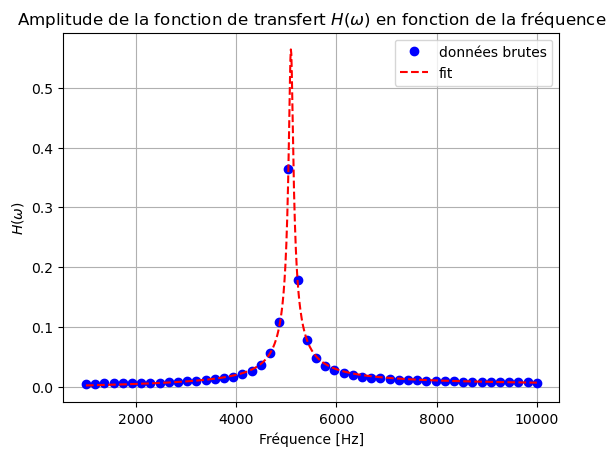

In [63]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes', color ='b')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='r')
plt.legend()

print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])
print(len(amp_np))
plt.grid()
plt.xlabel('Fréquence [Hz]')
plt.ylabel('$H( \omega )$')
plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


## R = 100 kOhm (bis)


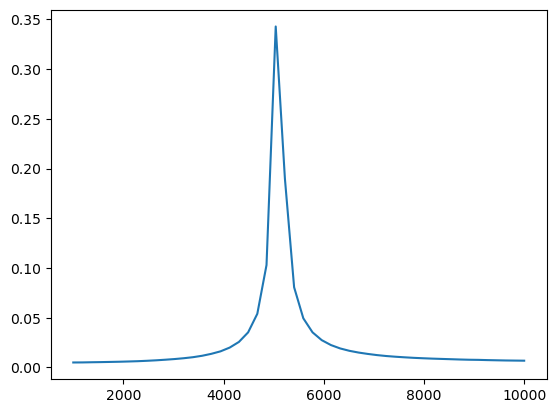

In [64]:
freq = pd.read_csv('Bode_100_bis.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100_bis.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

fréquence de résonance 32046.566672104243
facteur de qualité 69.02575728678396
Rp 88736.46397023537
Rp 38581.299852289994
Q_int 12.36398198012857
Valeur attendue de Quint 15.061886335888996
[5099.0990991]
50


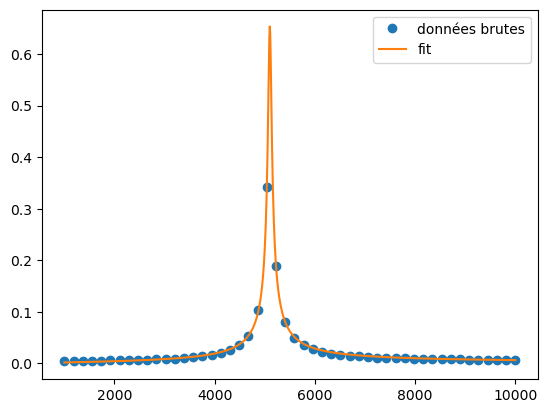

In [65]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])
print(len(amp_np))


## R = 218 kOhm

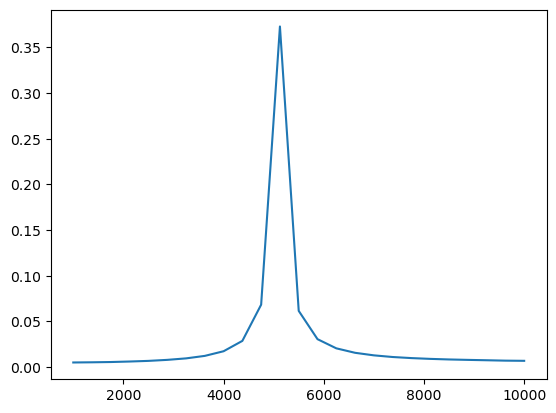

In [66]:
freq = pd.read_csv('Bode_278.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_278.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

Pulsation de résonance 31965.560779347306
facteur de qualité 49.737752848032855
Rp 40368.87814852261
Rp 67341.08638276088
Q_int 21.5259558971542
Valeur attendue de Qext 15.023813566293235
[5090.09009009]


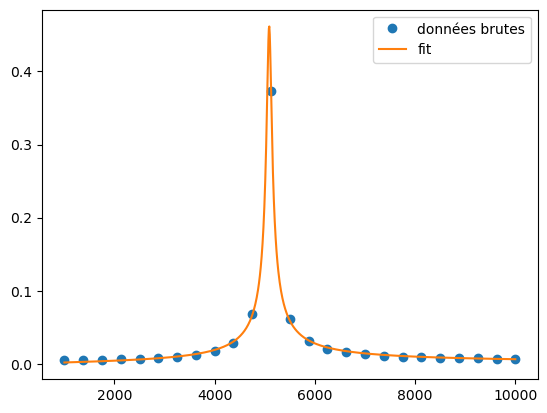

In [67]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi


plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('Pulsation de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Qext', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])

# Partie 4 - Démarage des oscillations


In [72]:
pd.read_csv('scopeData(23).csv')

,TIME ms,IN2
0,5.000,0.004799
1,4.990,-0.002525
2,4.980,-0.011314
3,4.971,-0.021568
4,4.961,-0.032066
...,...,...
1019,-4.951,-1.271568
1020,-4.961,-1.534508
1021,-4.971,-1.739830
1022,-4.980,-1.667320


In [145]:
time = pd.read_csv('scopeData(23).csv')['TIME ms']
Vin = pd.read_csv('scopeData(23).csv')[' IN2']
time = time.to_numpy()
Vin = Vin.to_numpy()
time_cropped, Vin_cropped = time[100:500], Vin[100:500]

In [148]:
def model(t, A, alpha, omega, phi):
    return A*np.exp(alpha*t)*np.cos(omega*t + phi)

p0 = (1.2, -0.7, 30, 0)

popt, pcov = curve_fit(model, time_cropped, Vin_cropped, p0)
A, alpha, omega, phi = popt

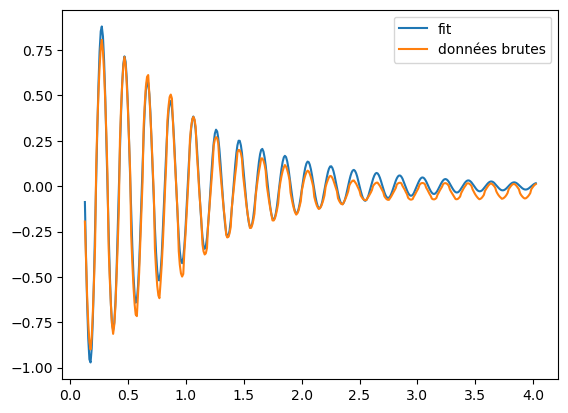

In [150]:
#plt.plot(time_cropped, model(time_cropped, *p0))
plt.plot(time_cropped, model(time_cropped, *popt), label ='fit')
plt.plot(time_cropped, Vin_cropped, label = 'données brutes')
plt.legend()
plt.show()

In [151]:
print(alpha)

-1.0490400132920974
